# Cascaded S-Matrix: Multiple Layers of Dielectric Cylinders

This notebook demonstrates the **Redheffer star product** cascade method.

A single slab of dielectric cylinders (n=1.3) is computed once, then cascaded
with itself to build multi-layer structures of 2, 10, and 20 identical layers.

**What this example demonstrates:**
1. Computing a single-layer S-matrix
2. Truncating evanescent modes before cascading (prevents $\tau^2 > 1$ artifacts)
3. Cascading via `cascadertwo()` — the Redheffer star product
4. How transmission decays with increasing layer count

In [1]:
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd

sys.path.insert(0, '../..')

from Scattering_Code.smatrix_parameters import smatrix_parameters
from Scattering_Code.smatrix import smatrix
from Scattering_Code.cascadertwo import cascadertwo

In [2]:
WAVELENGTH = 0.93
PERIOD     = 12.81
RADIUS     = 0.25
N_CYL_REF  = 1.3
MU         = 1.0
CMMAX      = 5
PHIINC     = np.pi / 2
Eva_TOL    = 1e-2
NUM_CYL    = 10
SEED       = 42

n_prop = int(np.floor(PERIOD / WAVELENGTH))
n_eva  = max(int(np.floor(
    PERIOD / (2*np.pi) * np.sqrt(
        (np.log(Eva_TOL) / (2*RADIUS))**2 + (2*np.pi/WAVELENGTH)**2
    )
)) - n_prop, 0)
nmax = n_prop + n_eva
nm   = 2 * nmax + 1
np_m = 2 * n_prop + 1  # propagating-only size

print(f"nmax = {nmax} (n_prop={n_prop}, n_eva={n_eva})")

nmax = 23 (n_prop=13, n_eva=10)


## 1. Compute Single-Layer S-Matrix

In [3]:
spacing = 2.5 * RADIUS
cyls_per_row = int(PERIOD / spacing)
rows_needed = NUM_CYL / cyls_per_row + 2
thickness = round(max(0.5, rows_needed * spacing * 1.5), 1)

rng = np.random.RandomState(SEED)
margin = RADIUS * 1.5
min_sep = 2.5 * RADIUS
clocs = np.zeros((NUM_CYL, 2))
for i in range(NUM_CYL):
    for _ in range(10000):
        x = margin + rng.rand() * (PERIOD - 2*margin)
        y = margin + rng.rand() * (thickness - 2*margin)
        if i == 0 or np.all(np.sqrt((x - clocs[:i, 0])**2 + (y - clocs[:i, 1])**2) > min_sep):
            clocs[i] = [x, y]
            break

sp = smatrix_parameters(WAVELENGTH, PERIOD, PHIINC,
                        1e-11, 1e-4, 5, 3, 1000, 3, 5, 1, PERIOD/120)
cmmaxs = np.full(NUM_CYL, CMMAX, dtype=int)
cepmus = np.column_stack([np.full(NUM_CYL, N_CYL_REF**2), np.full(NUM_CYL, MU)])
crads  = np.full(NUM_CYL, RADIUS)

print(f"Computing single-layer S-matrix ({NUM_CYL} cylinders, thickness={thickness})...")
t0 = time.time()
S_full, _ = smatrix(clocs, cmmaxs, cepmus, crads, PERIOD, WAVELENGTH,
                     nmax, thickness, sp, 'On')
print(f"Done in {time.time()-t0:.1f}s")

Computing single-layer S-matrix (10 cylinders, thickness=2.3)...
  Computing T-Matrix...
  transall: 45 pairs (43 spectral, 2 spatial [vectorized])
  T-Matrix: 0.1s
  LU Decomposition...
  LU: 0.0s
  Computing S11 & S21...
  DEBUG: C_up.shape=(110, 47), nmax=23, GPU=False
  DEBUG: W2_up.shape=(47, 110)
  DEBUG: s21matrix.shape=(47, 47)
  S11&S21: 0.0s
  Computing S12 & S22...
  S12&S22: 0.0s
  Total: 0.1s (0.0 min)
Done in 0.1s


## 2. Truncate Evanescent Modes Before Cascading

The Redheffer star product involves inverting $(I - S_{22}^A S_{11}^B)$.
Evanescent modes have large S-matrix entries that get amplified by this
inverse, causing $\tau^2 > 1$ artifacts. We truncate to propagating modes first.

In [4]:
def truncate_smatrix(S_full, nmax, n_eva):
    """Extract propagating-only block from full S-matrix."""
    if n_eva == 0:
        return S_full
    nm = 2 * nmax + 1
    p = slice(n_eva, nm - n_eva)
    return np.block([
        [S_full[p, p],          S_full[p, nm+n_eva:2*nm-n_eva]],
        [S_full[nm+n_eva:2*nm-n_eva, p], S_full[nm+n_eva:2*nm-n_eva, nm+n_eva:2*nm-n_eva]]
    ])

S_prop = truncate_smatrix(S_full, nmax, n_eva)
print(f"Full S-matrix: {S_full.shape} -> Propagating only: {S_prop.shape}")

Full S-matrix: (94, 94) -> Propagating only: (54, 54)


## 3. Cascade for 2, 10, 20 Layers

2 layers: max(tau^2) = 1.000000, sum(tau^2) = 22.5979
10 layers: max(tau^2) = 0.999838, sum(tau^2) = 14.2885
20 layers: max(tau^2) = 0.999930, sum(tau^2) = 11.1241


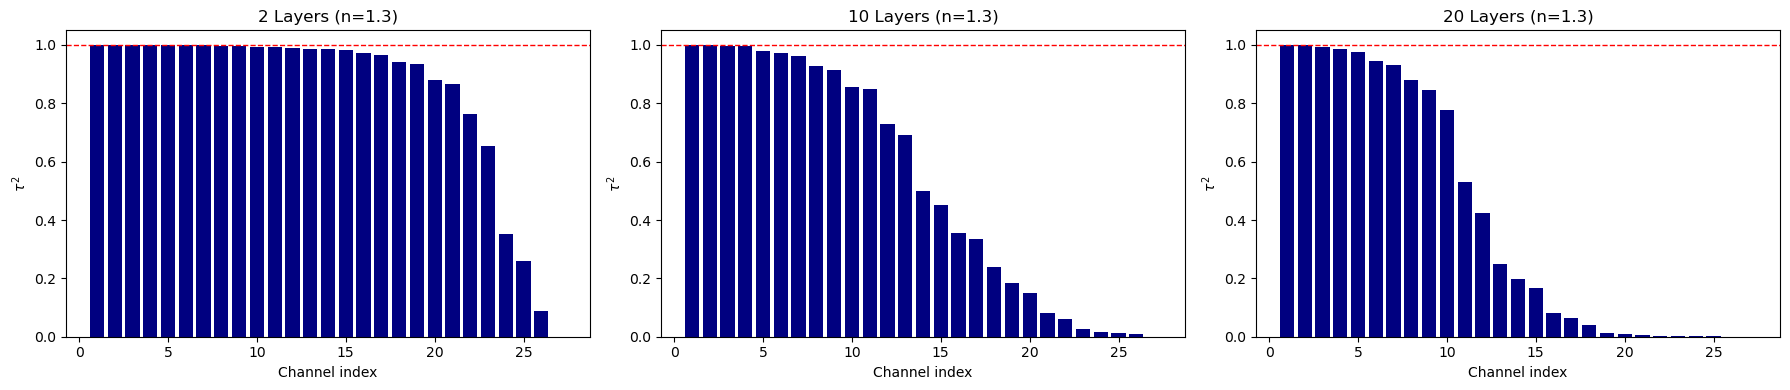

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for idx, n_layers in enumerate([2, 10, 20]):
    # Cascade
    S_cas = S_prop.copy()
    d_cas = thickness
    for _ in range(1, n_layers):
        S_cas, d_cas = cascadertwo(S_cas, d_cas, S_prop, thickness)
    
    # Transmission eigenvalues
    S21_cas = S_cas[np_m:, :np_m]
    tau = svd(S21_cas, compute_uv=False)
    
    print(f"{n_layers} layers: max(tau^2) = {np.max(tau**2):.6f}, sum(tau^2) = {np.sum(tau**2):.4f}")
    
    ax = axes[idx]
    ax.bar(range(1, len(tau)+1), tau**2, color='navy')
    ax.axhline(1.0, color='red', ls='--', lw=1)
    ax.set_xlabel('Channel index')
    ax.set_ylabel(r'$\tau^2$')
    ax.set_title(f'{n_layers} Layers (n={N_CYL_REF})')
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('dielectric_cascaded_singular_values.png', dpi=150)
plt.show()